In [1]:
!pip install spuco --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 62.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 4.3 MB/s eta 0:00:00


In [2]:
!nvidia-smi

Mon Jun  1 15:13:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import torch
from torch.optim import SGD
from spuco.utils import set_seed
from spuco.datasets import SpuCoMNIST, SpuriousFeatureDifficulty
from spuco.models import model_factory
from spuco.robust_train import ERM, GroupBalanceBatchERM
from spuco.group_inference import Cluster, ClusterAlg
from spuco.evaluate import Evaluator
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from itertools import product
import numpy as np

set_seed(0)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


The following code loads the dataset. The original ten MNIST digit labels are merged into five target classes: {0,1}, {2,3}, {4,5}, {6,7}, and {8,9}. The spurious-feature difficulty is set to large, so the injected spurious feature is easy for a model to learn.

In [4]:
# Data Loading
classes = [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]
difficulty = SpuriousFeatureDifficulty.MAGNITUDE_LARGE
train_set = SpuCoMNIST(
    root = "data/mnist/",
    classes = classes,
    spurious_feature_difficulty = difficulty,
    split = "train",
    spurious_correlation_strength=0.995
)
train_set.initialize()


val_set = SpuCoMNIST(
    root = "data/mnist/",
    classes = classes,
    spurious_feature_difficulty = difficulty,
    split = "val",
    spurious_correlation_strength=0.995
)
val_set.initialize()


test_set = SpuCoMNIST(
    root = "data/mnist/",
    classes = classes,
    spurious_feature_difficulty = difficulty,
    split="test",
    spurious_correlation_strength=0.995

)
test_set.initialize()

print(f"default train size: {len(train_set)}")
print(f"default val size: {len(val_set)}")
print(f"default test size: {len(test_set)}")



100%|██████████| 9.91M/9.91M [00:02<00:00, 4.78MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 126kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.34MB/s]


default train size: 48004
default val size: 11996
default test size: 10000


The dataset has up to 25 true groups: five target classes multiplied by five spurious-label values. With a spurious-correlation strength of 0.995, 99.5% of examples in target class c receive the matching spurious label c. Thus, groups such as (0,0), (1,1), and (4,4) are large majority groups, while mismatched pairs such as (0,1) are rare minority groups.

In [5]:
print("Train group sizes:")
for g, idx in sorted(train_set.group_partition.items()):
    print(f"  group {g}: {len(idx)} examples")


Train group sizes:
  group (0, 0): 10082 examples
  group (0, 1): 15 examples
  group (0, 2): 7 examples
  group (0, 3): 15 examples
  group (0, 4): 14 examples
  group (1, 0): 17 examples
  group (1, 1): 9623 examples
  group (1, 2): 9 examples
  group (1, 3): 12 examples
  group (1, 4): 11 examples
  group (2, 0): 7 examples
  group (2, 1): 18 examples
  group (2, 2): 8965 examples
  group (2, 3): 8 examples
  group (2, 4): 13 examples
  group (3, 0): 7 examples
  group (3, 1): 11 examples
  group (3, 2): 13 examples
  group (3, 3): 9698 examples
  group (3, 4): 18 examples
  group (4, 0): 13 examples
  group (4, 1): 12 examples
  group (4, 2): 13 examples
  group (4, 3): 10 examples
  group (4, 4): 9393 examples


## 3. Inspect the latent group distribution

The true group partition separates examples by target class and the value of the spurious attribute. A robust algorithm should not treat every example as identically distributed; it should account for minority groups whose shortcut pattern disagrees with the main class signal.

The printed counts show how skewed the training distribution is, which is the reason standard ERM can underestimate the difficulty of the task.



We first train a standard empirical risk minimization model using a LeNet backbone and SGD. This baseline  minimizes average training loss without correcting for group imbalance or spurious shortcuts.

The validation evaluator is attached so we can monitor performance without changing the training objective. This provides a baseline against which the group-aware model can be compared.


In [ ]:
epochs = 1
batch_sz = 64
lr = 1e-2

model = model_factory("lenet", train_set[0][0].shape, train_set.num_classes).to(DEVICE)

val_evaluator = Evaluator(
    testset=val_set,
    group_partition=val_set.group_partition,
    group_weights=train_set.group_weights,
    batch_size=batch_sz,
    model=model,
    device=DEVICE,
    verbose=False

)

erm = ERM(
    model = model,
    num_epochs = epochs,
    trainset = train_set,
    batch_size = batch_sz,
    optimizer=SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True),
    device=DEVICE,
    val_evaluator=val_evaluator,
    verbose= True
)

erm.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 0:   0%|          | 0/751 [00:00<?, ?batch/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_ratio

ERM | Epoch 0 | Loss: 1.6159987449645996 | Accuracy: 15.625%
ERM | Epoch 0 | Loss: 1.6190383434295654 | Accuracy: 23.4375%
ERM | Epoch 0 | Loss: 1.6121156215667725 | Accuracy: 23.4375%
ERM | Epoch 0 | Loss: 1.6064637899398804 | Accuracy: 18.75%
ERM | Epoch 0 | Loss: 1.6147704124450684 | Accuracy: 15.625%
ERM | Epoch 0 | Loss: 1.6145906448364258 | Accuracy: 14.0625%
ERM | Epoch 0 | Loss: 1.6029984951019287 | Accuracy: 21.875%
ERM | Epoch 0 | Loss: 1.6198844909667969 | Accuracy: 31.25%
ERM | Epoch 0 | Loss: 1.6045284271240234 | Accuracy: 25.0%
ERM | Epoch 0 | Loss: 1.6068167686462402 | Accuracy: 28.125%
ERM | Epoch 0 | Loss: 1.602858066558838 | Accuracy: 23.4375%
ERM | Epoch 0 | Loss: 1.5994164943695068 | Accuracy: 31.25%
ERM | Epoch 0 | Loss: 1.5935406684875488 | Accuracy: 23.4375%
ERM | Epoch 0 | Loss: 1.5979576110839844 | Accuracy: 28.125%
ERM | Epoch 0 | Loss: 1.6103147268295288 | Accuracy: 21.875%
ERM | Epoch 0 | Loss: 1.6000721454620361 | Accuracy: 25.0%
ERM | Epoch 0 | Loss: 1.592

Epoch 0:   6%|▌         | 42/751 [00:01<00:15, 46.46batch/s, accuracy=98.4375%, loss=0.346]

ERM | Epoch 0 | Loss: 1.580056071281433 | Accuracy: 37.5%
ERM | Epoch 0 | Loss: 1.573796033859253 | Accuracy: 40.625%
ERM | Epoch 0 | Loss: 1.574572205543518 | Accuracy: 37.5%
ERM | Epoch 0 | Loss: 1.5683462619781494 | Accuracy: 45.3125%
ERM | Epoch 0 | Loss: 1.5597832202911377 | Accuracy: 46.875%
ERM | Epoch 0 | Loss: 1.562186598777771 | Accuracy: 46.875%
ERM | Epoch 0 | Loss: 1.5569168329238892 | Accuracy: 42.1875%
ERM | Epoch 0 | Loss: 1.5490214824676514 | Accuracy: 43.75%
ERM | Epoch 0 | Loss: 1.5460972785949707 | Accuracy: 46.875%
ERM | Epoch 0 | Loss: 1.5412911176681519 | Accuracy: 53.125%
ERM | Epoch 0 | Loss: 1.5434775352478027 | Accuracy: 65.625%
ERM | Epoch 0 | Loss: 1.5188367366790771 | Accuracy: 82.8125%
ERM | Epoch 0 | Loss: 1.5016244649887085 | Accuracy: 82.8125%
ERM | Epoch 0 | Loss: 1.5015769004821777 | Accuracy: 76.5625%
ERM | Epoch 0 | Loss: 1.4814060926437378 | Accuracy: 84.375%
ERM | Epoch 0 | Loss: 1.4596060514450073 | Accuracy: 64.0625%
ERM | Epoch 0 | Loss: 1.433

Epoch 0:  10%|▉         | 74/751 [00:01<00:08, 83.77batch/s, accuracy=100.0%, loss=0.00562]

...

ERM | Epoch 0 | Loss: 0.00360066257417202 | Accuracy: 100.0%
ERM | Epoch 0 | Loss: 0.003874965477734804 | Accuracy: 100.0%
ERM | Epoch 0 | Loss: 0.002890655305236578 | Accuracy: 100.0%
ERM | Epoch 0 | Loss: 0.0032629636116325855 | Accuracy: 100.0%
ERM | Epoch 0 | Loss: 0.0030082548037171364 | Accuracy: 100.0%
ERM | Epoch 0 | Loss: 0.003170754760503769 | Accuracy: 100.0%
ERM | Epoch 0 | Loss: 0.1501970738172531 | Accuracy: 98.4375%
ERM | Epoch 0 | Loss: 0.0029202131554484367 | Accuracy: 100.0%
ERM | Epoch 0 | Loss: 0.11347824335098267 | Accuracy: 98.4375%
ERM | Epoch 0 | Loss: 0.0023646331392228603 | Accuracy: 100.0%
ERM | Epoch 0 | Loss: 0.003207279834896326 | Accuracy: 100.0%
ERM | Epoch 0 | Loss: 0.002922764979302883 | Accuracy: 100.0%
ERM | Epoch 0 | Loss: 0.002836325205862522 | Accuracy: 100.0%
ERM | Epoch 0 | Loss: 0.10827474296092987 | Accuracy: 98.4375%
ERM | Epoch 0 | Loss: 0.12195789068937302 | Accuracy: 98.4375%
ERM | Epoch 0 | Loss: 0.004164164420217276 | Accuracy: 100.0%
ER

Epoch 0: 100%|██████████| 751/751 [00:06<00:00, 113.95batch/s, accuracy=100.0%, loss=0.0107]


ERM | Epoch 0 | Loss: 0.010742006823420525 | Accuracy: 100.0%


Evaluating group-wise accuracy: 100%|██████████| 25/25 [00:08<00:00,  3.00it/s]

Epoch 0: ERM Val Worst-Group Accuracy: 0.0
Best Val Worst-Group Accuracy: 0.0


After the ERM model has been trained, we use its logits—the model's raw output scores for each class—to summarize its behavior on each example. The `Cluster` object groups examples within each class into two clusters, approximating the latent spurious subgroups. These are inferred groups: five target classes multiplied by two K-means clusters, for up to ten groups total.


In [8]:
# Clustering
logits = erm.trainer.get_trainset_outputs()
cluster = Cluster(Z=logits, cluster_alg = ClusterAlg.KMEANS,
                  class_labels= train_set.labels, num_clusters=2,
                  device=DEVICE, verbose= True)
group_partition= cluster.infer_groups()
print(group_partition[(0, 0)])

Clustering class-wise: 100%|██████████| 5/5 [00:00<00:00,  9.09it/s]


[1, 3, 6, 8, 18, 20, 21, 31, 34, 37, 48, 53, 60, 61, 62, 64, 67, 68, 71, 75, 80, 85, 88, 92, 93, 94, 98, 99, 101, 104, 108, 113, 124, 128, 139, 143, 151, 163, 164, 167, 168, 170, 171, 172, 184, 187, 199, 201, 208, 214, 219, 224, 231, 235, 242, 249, 254, 259, 281, 282, 283, 290, 304, 313, 315, 316, 323, 330, 339, 341, 350, 351, 356, 357, 358, 359, 362, 365, 367, 369, 372, 375, 376, 382, 386, 387, 397, 398, 400, 408, 412, 414, 419, 421, 424, 427, 436, 437, 439, 451, 452, 455, 459, 464, 470, 473, 480, 481, 485, 487, 492, 503, 507, 516, 521, 527, 531, 532, 533, 534, 536, 541, 550, 552, 565, 566, 567, 568, 583, 588, 592, 594, 608, 617, 620, 621, 623, 627, 630, 648, 656, 659, 673, 692, 699, 700, 713, 722, 724, 736, 737, 743, 752, 754, 761, 762, 768, 770, 774, 786, 787, 789, 791, 799, 801, 803, 804, 805, 813, 815, 817, 818, 827, 829, 840, 842, 845, 847, 854, 859, 862, 866, 867, 869, 870, 872, 873, 879, 881, 888, 892, 899, 902, 905, 910, 913, 914, 919, 930, 933, 936, 946, 949, 953, 955, 965, 9



The next plot projects each class's logits into two principal components and colors points by the inferred cluster assignment. The top row shows whether the clustering separates examples in a way that matches the model's learned grouping; the bottom row overlays the true spurious label to assess whether the inferred groups correspond to the underlying shortcut feature.


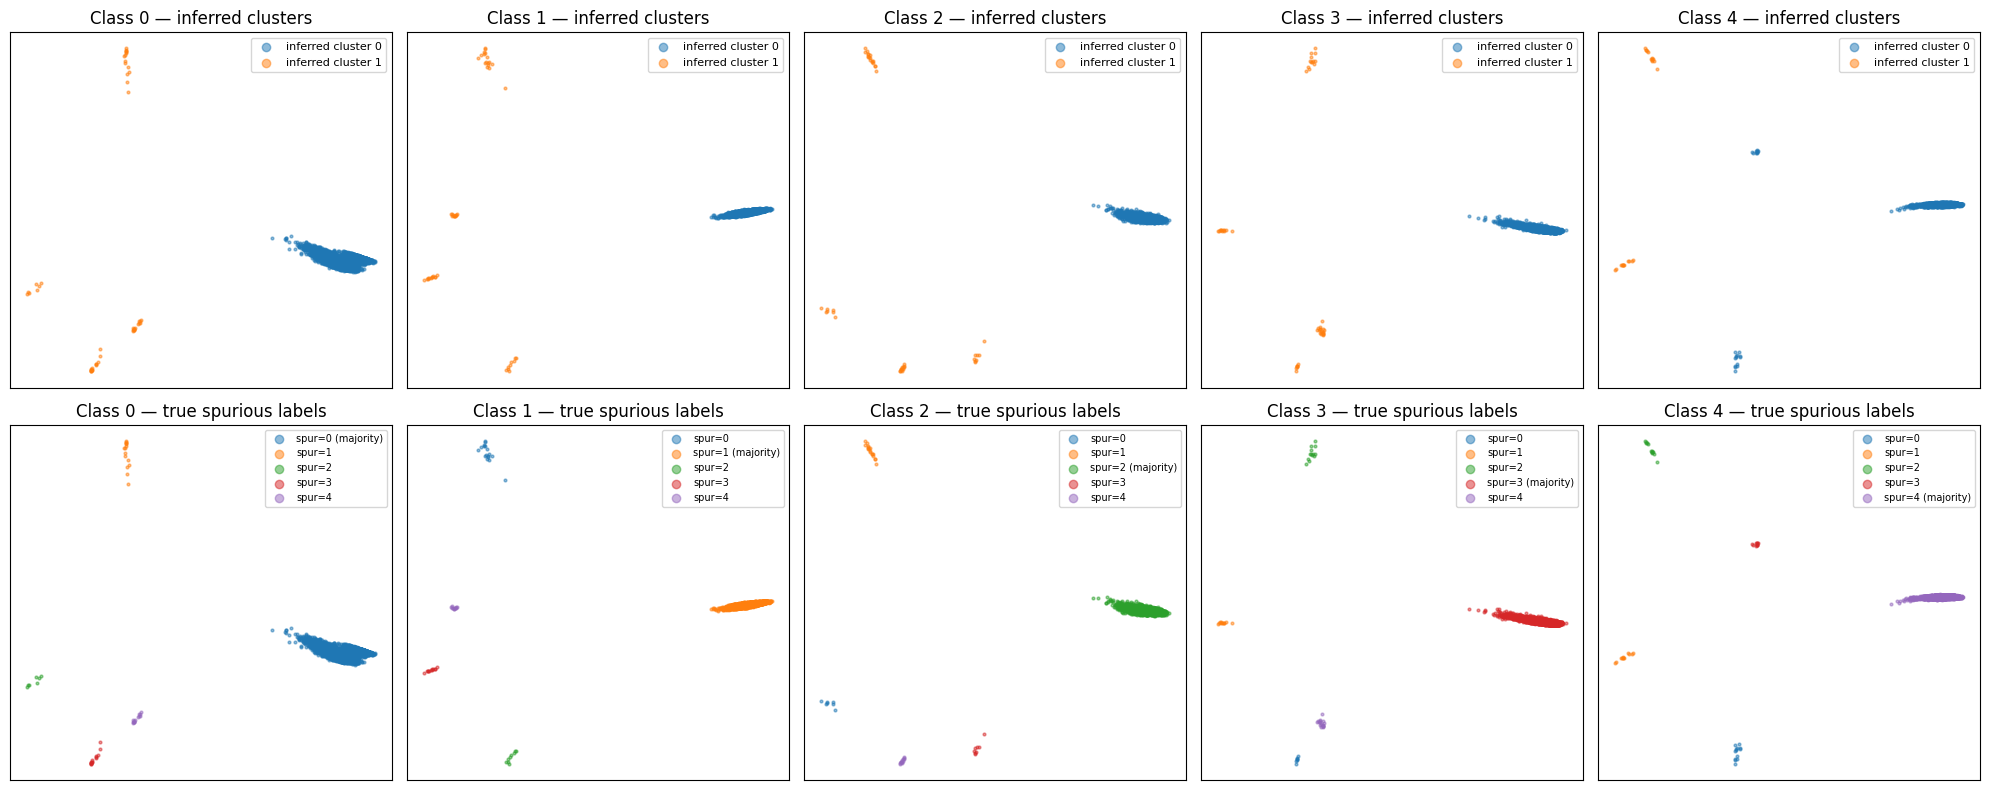

In [9]:
logits_np = logits.cpu().numpy() if hasattr(logits, 'cpu') else np.array(logits)
labels_np = np.array(train_set.labels)
spurious_np = np.array(train_set.spurious)

num_classes = 5
fig, axes = plt.subplots(2, num_classes, figsize=(4 * num_classes, 8))

for c in range(num_classes):
    # Get this class's examples
    class_mask = labels_np == c
    class_logits = logits_np[class_mask]
    class_spurious = spurious_np[class_mask]

    # Recover the inferred cluster assignment for each example in this class
    cluster_assignment = np.zeros(class_mask.sum(), dtype=int)
    class_indices = np.where(class_mask)[0]
    for cluster_id in range(2):
        group_idx = np.array(group_partition[(c, cluster_id)])
        # group_idx are absolute indices; convert to positions within this class
        positions = np.searchsorted(class_indices, group_idx)
        cluster_assignment[positions] = cluster_id

    # PCA to 2D
    pca = PCA(n_components=2)
    coords = pca.fit_transform(class_logits)

    # Top row: colored by inferred cluster
    ax = axes[0, c]
    for cluster_id in range(2):
        m = cluster_assignment == cluster_id
        ax.scatter(coords[m, 0], coords[m, 1], s=4, alpha=0.5,
                   label=f"inferred cluster {cluster_id}")
    ax.set_title(f"Class {c} — inferred clusters")
    ax.legend(markerscale=3, fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

    # Bottom row: colored by TRUE spurious label (for sanity check)
    ax = axes[1, c]
    for s in range(num_classes):
        m = class_spurious == s
        if m.sum() == 0:
            continue
        is_majority = (s == c)
        ax.scatter(coords[m, 0], coords[m, 1], s=4, alpha=0.5,
                   label=f"spur={s}" + (" (majority)" if is_majority else ""))
    ax.set_title(f"Class {c} — true spurious labels")
    ax.legend(markerscale=3, fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

The following sanity check compares the inferred groups to the canonical majority spurious label. In SpuCoMNIST, the majority spurious label for class `c` is typically `c` itself, which means the dominant pattern in each class is aligned with the target. Minority groups are the examples where the spurious attribute disagrees with the class label.

In [11]:
#Sanity check
spurious = np.array(train_set.spurious)
labels   = np.array(train_set.labels)
print(f"{'inferred group':>18} | {'size':>6} | spurious-label distribution")
print("-" * 70)
for g, idx in sorted(group_partition.items()):
    idx = np.array(idx)
    cls = g[0]
    spur_in_grp = spurious[idx]
    # The canonical/majority spurious label for class c is c itself in SpuCoMNIST.
    frac_majority = (spur_in_grp == cls).mean()
    print(f"  {str(g):>16} | {len(idx):>6d} | majority-spurious fraction = {frac_majority:.3f}")

    inferred group |   size | spurious-label distribution
----------------------------------------------------------------------
            (0, 0) |  10082 | majority-spurious fraction = 1.000
            (0, 1) |     51 | majority-spurious fraction = 0.000
            (1, 0) |   9623 | majority-spurious fraction = 1.000
            (1, 1) |     49 | majority-spurious fraction = 0.000
            (2, 0) |   8965 | majority-spurious fraction = 1.000
            (2, 1) |     46 | majority-spurious fraction = 0.000
            (3, 0) |   9698 | majority-spurious fraction = 1.000
            (3, 1) |     49 | majority-spurious fraction = 0.000
            (4, 0) |   9416 | majority-spurious fraction = 0.998
            (4, 1) |     25 | majority-spurious fraction = 0.000



The next stage switches from standard ERM to a group-balanced optimization scheme. The model architecture is identical to the baseline, but training batches are balanced across the inferred groups so that minority groups are not underrepresented during optimization.


In [ ]:
# Training a group balanced model
balanced_model = model_factory("lenet", train_set[0][0].shape, train_set.num_classes).to(DEVICE)

gb_val_evaluator = Evaluator(
    testset=val_set,
    group_partition=val_set.group_partition,
    group_weights=train_set.group_weights,
    batch_size=64,
    model=balanced_model,
    device=DEVICE,
    verbose=False,
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


This model is trained using `GroupBalanceBatchERM`, which explicitly balances batches according to the inferred groups instead of treating all examples equally. This helps prevent the dominant group from overwhelming the optimization signal and encourages the network to rely on the invariant digit structure rather than the spurious attribute.

The `best_model` is retained so that the strongest validation checkpoint can be evaluated on the held-out test set.

In [ ]:
group_balance_erm = GroupBalanceBatchERM(
    model=balanced_model,
    num_epochs=20,
    trainset=train_set,
    group_partition=group_partition,
    batch_size=32,
    optimizer=SGD(balanced_model.parameters(), lr=1e-2, weight_decay=1e-3, momentum=0.9, nesterov=True),
    device=DEVICE,
    val_evaluator=gb_val_evaluator,
    verbose=True
)


group_balance_erm.train()
final_model = group_balance_erm.best_model if group_balance_erm.best_model is not None else balanced_model

george_evaluator = Evaluator(
    testset=test_set,
    group_partition=test_set.group_partition,
    group_weights=train_set.group_weights,
    batch_size=64,
    model=final_model,
    device=DEVICE,
    verbose=True
)
george_evaluator.evaluate()

print(f"\n[GEORGE] Average accuracy:     {george_evaluator.average_accuracy:.2f}%")
print(f"[GEORGE] Worst-group accuracy: {george_evaluator.worst_group_accuracy[1]:.2f}%")

Epoch 0:   0%|          | 0/1501 [00:00<?, ?batch/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 0:   1%|          | 17/1501 [00:00<00:22, 65.36batch/s, accuracy=28.125%, loss=1.6]

GB | Epoch 0 | Loss: 1.6080846786499023 | Accuracy: 28.125%
GB | Epoch 0 | Loss: 1.5971519947052002 | Accuracy: 28.125%
GB | Epoch 0 | Loss: 1.594150424003601 | Accuracy: 28.125%
GB | Epoch 0 | Loss: 1.6332112550735474 | Accuracy: 12.5%
GB | Epoch 0 | Loss: 1.6111012697219849 | Accuracy: 12.5%
GB | Epoch 0 | Loss: 1.625280499458313 | Accuracy: 18.75%
GB | Epoch 0 | Loss: 1.597167730331421 | Accuracy: 43.75%
GB | Epoch 0 | Loss: 1.6091835498809814 | Accuracy: 21.875%
GB | Epoch 0 | Loss: 1.6289304494857788 | Accuracy: 15.625%
GB | Epoch 0 | Loss: 1.60346257686615 | Accuracy: 34.375%
GB | Epoch 0 | Loss: 1.6015625 | Accuracy: 25.0%
GB | Epoch 0 | Loss: 1.6089192628860474 | Accuracy: 15.625%
GB | Epoch 0 | Loss: 1.608109712600708 | Accuracy: 28.125%
GB | Epoch 0 | Loss: 1.621948480606079 | Accuracy: 28.125%
GB | Epoch 0 | Loss: 1.6168147325515747 | Accuracy: 31.25%
GB | Epoch 0 | Loss: 1.6076321601867676 | Accuracy: 25.0%
GB | Epoch 0 | Loss: 1.602601408958435 | Accuracy: 28.125%
GB | Epo

Epoch 0:   3%|▎         | 49/1501 [00:00<00:12, 118.55batch/s, accuracy=21.875%, loss=1.6]

GB | Epoch 0 | Loss: 1.6044666767120361 | Accuracy: 28.125%
GB | Epoch 0 | Loss: 1.6053675413131714 | Accuracy: 25.0%
GB | Epoch 0 | Loss: 1.603607416152954 | Accuracy: 43.75%
GB | Epoch 0 | Loss: 1.6033172607421875 | Accuracy: 34.375%
GB | Epoch 0 | Loss: 1.6035960912704468 | Accuracy: 31.25%
GB | Epoch 0 | Loss: 1.6053087711334229 | Accuracy: 28.125%
GB | Epoch 0 | Loss: 1.6009624004364014 | Accuracy: 43.75%
GB | Epoch 0 | Loss: 1.6033062934875488 | Accuracy: 28.125%
GB | Epoch 0 | Loss: 1.602996587753296 | Accuracy: 31.25%
GB | Epoch 0 | Loss: 1.6033756732940674 | Accuracy: 37.5%
GB | Epoch 0 | Loss: 1.5993705987930298 | Accuracy: 34.375%
GB | Epoch 0 | Loss: 1.613585352897644 | Accuracy: 15.625%
GB | Epoch 0 | Loss: 1.5976771116256714 | Accuracy: 40.625%
GB | Epoch 0 | Loss: 1.605208396911621 | Accuracy: 21.875%
GB | Epoch 0 | Loss: 1.5994151830673218 | Accuracy: 34.375%
GB | Epoch 0 | Loss: 1.6106196641921997 | Accuracy: 18.75%
GB | Epoch 0 | Loss: 1.6088690757751465 | Accuracy: 2

Epoch 0:   6%|▌         | 85/1501 [00:00<00:09, 149.81batch/s, accuracy=50.0%, loss=1.53]

...

Group (4, 2) Accuracy: 45.84382871536524


Evaluating group-wise accuracy:  96%|█████████▌| 24/25 [00:12<00:00,  2.07it/s]

Group (4, 3) Accuracy: 33.83838383838384


Evaluating group-wise accuracy: 100%|██████████| 25/25 [00:12<00:00,  1.93it/s]

Group (4, 4) Accuracy: 99.74747474747475

[GEORGE] Average accuracy:     99.60%
[GEORGE] Worst-group accuracy: 33.84%


The final checkpoint is evaluated on the test distribution with group-aware metrics. 
The printed metrics report both the average test accuracy and the worst-group accuracy, which is often the most informative metric for spurious-correlation problems.


In [16]:
print("\nPer-group test accuracy (GEORGE):")
for g in sorted(test_set.group_partition.keys()):
    acc = george_evaluator.accuracies[g]
    print(f"  group {g}: {acc:.1f}%")


Per-group test accuracy (GEORGE):
  group (0, 0): 99.8%
  group (0, 1): 80.6%
  group (0, 2): 79.4%
  group (0, 3): 78.3%
  group (0, 4): 87.0%
  group (1, 0): 81.9%
  group (1, 1): 99.5%
  group (1, 2): 80.1%
  group (1, 3): 78.9%
  group (1, 4): 62.0%
  group (2, 0): 77.9%
  group (2, 1): 76.8%
  group (2, 2): 100.0%
  group (2, 3): 60.8%
  group (2, 4): 43.3%
  group (3, 0): 76.4%
  group (3, 1): 69.3%
  group (3, 2): 75.6%
  group (3, 3): 99.7%
  group (3, 4): 74.3%
  group (4, 0): 64.0%
  group (4, 1): 51.1%
  group (4, 2): 45.8%
  group (4, 3): 33.8%
  group (4, 4): 99.7%
